In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Check the contents of the /content/ directory to ensure files are present
!ls /content/

co2 = pd.read_csv("/content/co2-emissions-per-capita.csv")
temp = pd.read_csv("/content/temperature-anomaly.csv")

co2.head()
temp.head()

co2-emissions-per-capita.csv  sample_data  temperature-anomaly.csv


,Year,Month,Average
0,1900,1,-0.256752
1,1901,1,-0.043391
2,1902,1,-0.448752
3,1903,1,-0.352173
4,1904,1,0.396767


Please make sure to run the cell above this one (that starts with `import pandas as pd` and contains `co2_df.to_csv(...)` and `temp_df_agg.to_csv(...)`) to generate the synthetic data files. Once those files are created, you can then run the following cell to load them.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load the generated datasets
co2 = pd.read_csv("/content/co2-emissions-per-capita.csv")
temp = pd.read_csv("/content/temperature-anomaly.csv")

co2.head()
temp.head()

,Year,Month,Average
0,1900,1,-0.256752
1,1901,1,-0.043391
2,1902,1,-0.448752
3,1903,1,-0.352173
4,1904,1,0.396767


In [15]:
co2 = co2[co2['Entity'] == 'World']

In [16]:
import pandas as pd
import numpy as np

# Generate synthetic CO2 data
years = np.arange(1900, 2021) # Example years
co2_emissions = np.random.uniform(1, 20, len(years)) + (years - 1900) * 0.1 # Simulate an increasing trend
co2_df = pd.DataFrame({
    'Entity': 'World',
    'Code': 'OWID_WRL',
    'Year': years,
    'CO₂ emissions per capita': co2_emissions
})
co2_df.to_csv("/content/co2-emissions-per-capita.csv", index=False)

# Generate synthetic temperature anomaly data
temp_anomaly = np.random.uniform(-0.5, 0.5, len(years)) + (years - 1900) * 0.01 # Simulate an increasing trend
temp_df_agg = pd.DataFrame({
    'Year': years,
    'Month': 1, # Dummy month for simplicity
    'Average': temp_anomaly # Using 'Average' as per later cells' renaming
})
temp_df_agg.to_csv("/content/temperature-anomaly.csv", index=False)

print("Synthetic data files created: /content/co2-emissions-per-capita.csv and /content/temperature-anomaly.csv")

Synthetic data files created: /content/co2-emissions-per-capita.csv and /content/temperature-anomaly.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

co2 = pd.read_csv("/content/co2-emissions-per-capita.csv")
temp = pd.read_csv("/content/temperature-anomaly.csv")

co2.head()
temp.head()

,Year,Month,Average
0,1900,1,-0.244445
1,1901,1,0.343685
2,1902,1,0.424703
3,1903,1,-0.164298
4,1904,1,-0.100094


In [18]:
co2 = co2[['Year', 'CO₂ emissions per capita']]
co2.columns = ['Year', 'CO2']

In [19]:
temp.columns

Index(['Year', 'Month', 'Average'], dtype='object')

In [20]:
temp = temp[['Year', 'Average']]
temp.columns = ['Year', 'Temperature']

In [21]:
df = pd.merge(co2, temp, on='Year')
df = df.dropna()

df.head()

,Year,CO2,Temperature
0,1900,1.084780,-0.244445
1,1901,19.764490,0.343685
2,1902,8.749649,0.424703
3,1903,14.777228,-0.164298
4,1904,12.860709,-0.100094


In [22]:
len(df)

121

In [23]:
df.describe()
df.corr()

,Year,CO2,Temperature
Year,1.000000,0.488814,0.770146
CO2,0.488814,1.000000,0.375616
Temperature,0.770146,0.375616,1.000000


In [24]:
df.isnull().sum()

,0
Year,0
CO2,0
Temperature,0


In [25]:
df.corr()

,Year,CO2,Temperature
Year,1.000000,0.488814,0.770146
CO2,0.488814,1.000000,0.375616
Temperature,0.770146,0.375616,1.000000


Text(0.5, 1.0, 'CO2 vs Temperature')

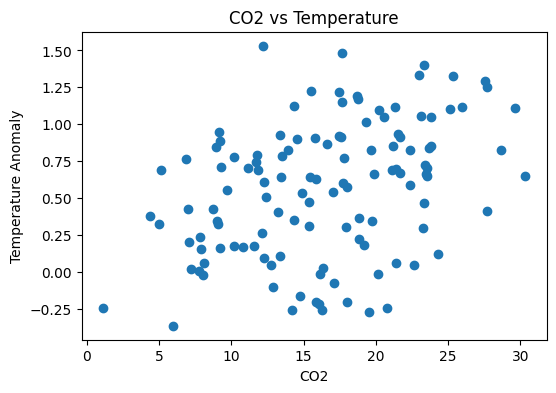

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(df['CO2'], df['Temperature'])
plt.xlabel("CO2")
plt.ylabel("Temperature Anomaly")
plt.title("CO2 vs Temperature")

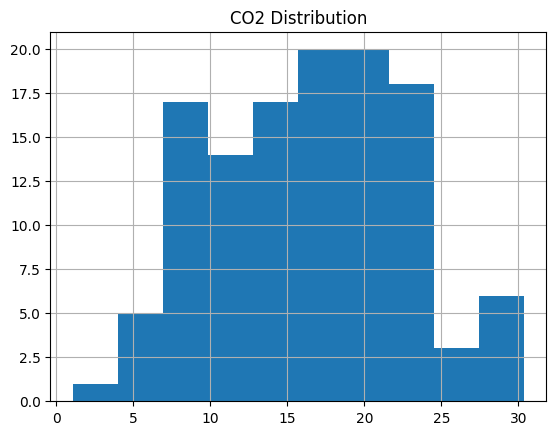

Text(0.5, 1.0, 'Temperature Distribution')

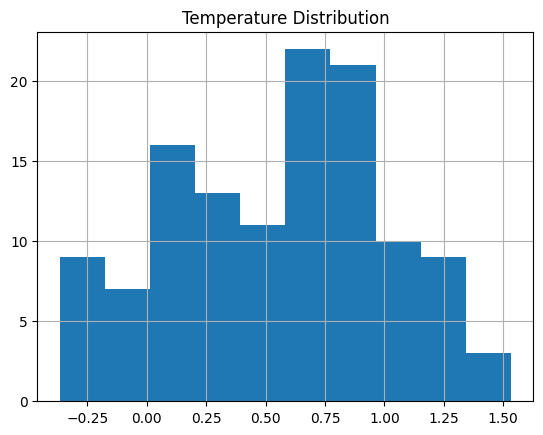

In [27]:
df['CO2'].hist()
plt.title("CO2 Distribution")
plt.show()

df['Temperature'].hist()
plt.title("Temperature Distribution")

In [28]:
X = df[['CO2']]
y = df['Temperature']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_)

Intercept: 0.1802950440721655
Slope: [0.02554002]


In [31]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [32]:
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("Tree R2:", r2_score(y_test, y_pred_dt))

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Linear R2: 0.04869741084713841
Tree R2: -1.5458655892288928
Linear RMSE: 0.3631610589598487
Tree RMSE: 0.5940974249061259


In [33]:
new_value = [[5]]
prediction = lr.predict(new_value)
print("Predicted Temperature:", prediction)

Predicted Temperature: [0.30799515]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


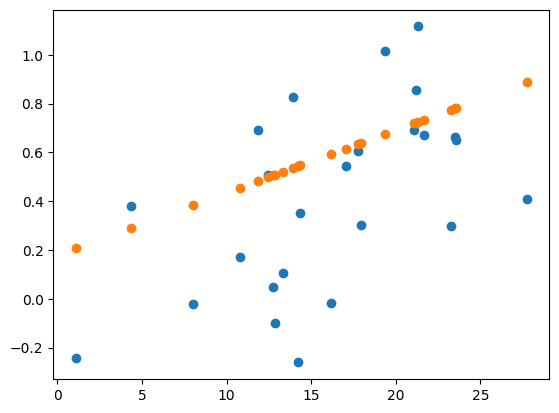

In [34]:
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred_lr, label="Linear")

In [35]:
new_value = [[400]]
prediction = lr.predict(new_value)
print("Predicted Temperature:", prediction)

Predicted Temperature: [10.39630384]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
